In [2]:
# Importación de Librerías Esenciales

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt


from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# Cargar el dataset Ames Housing desde OpenML
housing = fetch_openml(name="house_prices", as_frame=True)
df = housing.frame

# Seleccionamos un subconjunto de características numéricas para simplificar el taller
# y la variable objetivo 'SalePrice'
numeric_features = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'FullBath', 'GarageCars', 'OpenPorchSF']
target_variable = 'SalePrice'


# Creamos un DataFrame más pequeño y manejamos valores faltantes de forma simple
df_subset = df[numeric_features + [target_variable]].dropna()

print(f"\nDimensiones del subconjunto de datos: {df_subset.shape}")
print("\nDescripción estadística del subconjunto:")
print(df_subset.describe())


Dimensiones del subconjunto de datos: (1460, 8)

Descripción estadística del subconjunto:
         GrLivArea  OverallQual    YearBuilt  TotalBsmtSF     FullBath  \
count  1460.000000  1460.000000  1460.000000  1460.000000  1460.000000   
mean   1515.463699     6.099315  1971.267808  1057.429452     1.565068   
std     525.480383     1.382997    30.202904   438.705324     0.550916   
min     334.000000     1.000000  1872.000000     0.000000     0.000000   
25%    1129.500000     5.000000  1954.000000   795.750000     1.000000   
50%    1464.000000     6.000000  1973.000000   991.500000     2.000000   
75%    1776.750000     7.000000  2000.000000  1298.250000     2.000000   
max    5642.000000    10.000000  2010.000000  6110.000000     3.000000   

        GarageCars  OpenPorchSF      SalePrice  
count  1460.000000  1460.000000    1460.000000  
mean      1.767123    46.660274  180921.195890  
std       0.747315    66.256028   79442.502883  
min       0.000000     0.000000   34900.000000

In [4]:
# Histograma del Precio de Venta (SalePrice)
fig_hist = px.histogram(df_subset, x='SalePrice', nbins=50, title='Distribución del Precio de Venta de las Casas (Original)')
fig_hist.update_layout(xaxis_title='Precio de Venta (USD)', yaxis_title='Frecuencia')
fig_hist.show()

# Histograma del log(Precio de Venta)
fig_hist_log = px.histogram(x=np.log1p(df_subset['SalePrice']), nbins=50, title='Distribución del log(Precio de Venta)')
fig_hist_log.update_layout(xaxis_title='log(1 + Precio de Venta)', yaxis_title='Frecuencia')
fig_hist_log.show()

In [5]:
# 1. Definir características (X) y objetivo (y)
X = df_subset[numeric_features]
y_raw = df_subset[target_variable] # Guardamos el 'y' original para evaluación final



# !! CAMBIO CLAVE !!
# Aplicamos la transformación logarítmica a la variable objetivo 'y'
# Esto estabiliza la varianza y normaliza la escala del problema.
y = np.log1p(y_raw)

# 2. Dividir en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")

# 3. Escalar las características numéricas
scaler = StandardScaler()

# Ajustamos el escalador SOLO con los datos de entrenamiento para evitar fuga de datos (data leakage)
X_train_scaled = scaler.fit_transform(X_train)
# Aplicamos la misma transformación a los datos de prueba
X_test_scaled = scaler.transform(X_test)

# Convertimos los arrays de numpy de vuelta a DataFrames de pandas para mejor legibilidad
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_features)

Tamaño del set de entrenamiento: (1168, 7)
Tamaño del set de prueba: (292, 7)


In [6]:
# Crear y entrenar el modelo de Regresión Lineal
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Realizar predicciones en el conjunto de prueba (las predicciones estarán en escala logarítmica)
y_pred_ols = ols_model.predict(X_test_scaled)

# Evaluar el modelo
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

print("--- Evaluación del Modelo de Regresión Lineal (OLS) ---")
print(f"Error Cuadrático Medio (MSE en escala log): {mse_ols:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_ols:.4f}")

# Ver los coeficientes del modelo
coef_df = pd.DataFrame(ols_model.coef_, index=numeric_features, columns=['Coeficiente_OLS'])
print("\nCoeficientes del modelo OLS:")
print(coef_df)

--- Evaluación del Modelo de Regresión Lineal (OLS) ---
Error Cuadrático Medio (MSE en escala log): 0.0303
Coeficiente de Determinación (R²): 0.8375

Coeficientes del modelo OLS:
             Coeficiente_OLS
GrLivArea           0.126057
OverallQual         0.138204
YearBuilt           0.074256
TotalBsmtSF         0.044341
FullBath           -0.007015
GarageCars          0.071633
OpenPorchSF         0.002387


In [7]:
# --- Ridge Regression (L2) ---
ridge_model = Ridge(alpha=100.) # Alpha grande
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("--- Evaluación del Modelo Ridge (alpha=100.) ---")
print(f"Error Cuadrático Medio (MSE en escala log): {mse_ridge:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_ridge:.4f}")

# --- Lasso Regression (L1) ---
lasso_model = Lasso(alpha=0.1) # Alpha pequeño
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n--- Evaluación del Modelo Lasso (alpha=0.1) ---")
print(f"Error Cuadrático Medio (MSE en escala log): {mse_lasso:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_lasso:.4f}")

# Comparar coeficientes
coef_df['Coef_Ridge_alpha100'] = ridge_model.coef_
coef_df['Coef_Lasso_alpha0.1'] = lasso_model.coef_
print("\n--- Comparación de Coeficientes ---")
print(coef_df.round(4))

--- Evaluación del Modelo Ridge (alpha=100.) ---
Error Cuadrático Medio (MSE en escala log): 0.0310
Coeficiente de Determinación (R²): 0.8340

--- Evaluación del Modelo Lasso (alpha=0.1) ---
Error Cuadrático Medio (MSE en escala log): 0.0579
Coeficiente de Determinación (R²): 0.6895

--- Comparación de Coeficientes ---
             Coeficiente_OLS  Coef_Ridge_alpha100  Coef_Lasso_alpha0.1
GrLivArea             0.1261               0.1109               0.0567
OverallQual           0.1382               0.1280               0.1479
YearBuilt             0.0743               0.0670               0.0050
TotalBsmtSF           0.0443               0.0494               0.0060
FullBath             -0.0070               0.0077               0.0000
GarageCars            0.0716               0.0725               0.0486
OpenPorchSF           0.0024               0.0058               0.0000


In [34]:
# Definir un rango de alphas para probar
alphas = np.logspace(-4, 2, 100)

# --- RidgeCV ---
ridge_cv = RidgeCV(alphas=alphas, store_cv_results=True)
ridge_cv.fit(X_train_scaled, y_train)

print("--- Búsqueda del mejor Alpha para Ridge ---")
print(f"Mejor alpha encontrado para Ridge: {ridge_cv.alpha_:.4f}")

# Evaluar el modelo Ridge final con el mejor alpha
y_pred_ridge_cv = ridge_cv.predict(X_test_scaled)
mse_ridge_cv = mean_squared_error(y_test, y_pred_ridge_cv)
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)
print(f"MSE de Ridge con CV: {mse_ridge_cv:.4f}")
print(f"R² de Ridge con CV: {r2_ridge_cv:.4f}")

# --- LassoCV ---
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print("\n--- Búsqueda del mejor Alpha para Lasso ---")
print(f"Mejor alpha encontrado para Lasso: {lasso_cv.alpha_:.4f}")

# Evaluar el modelo Lasso final
y_pred_lasso_cv = lasso_cv.predict(X_test_scaled)
mse_lasso_cv = mean_squared_error(y_test, y_pred_lasso_cv)
r2_lasso_cv = r2_score(y_test, y_pred_lasso_cv)
print(f"MSE de Lasso con CV: {mse_lasso_cv:.4f}")
print(f"R² de Lasso con CV: {r2_lasso_cv:.4f}")

# Añadir los coeficientes finales al DataFrame
coef_df['Coef_Ridge_CV'] = ridge_cv.coef_
coef_df['Coef_Lasso_CV'] = lasso_cv.coef_
print("\n--- Comparación Final de Coeficientes ---")
print(coef_df.round(4))

--- Búsqueda del mejor Alpha para Ridge ---
Mejor alpha encontrado para Ridge: 86.9749
MSE de Ridge con CV: 0.0309
R² de Ridge con CV: 0.8346

--- Búsqueda del mejor Alpha para Lasso ---
Mejor alpha encontrado para Lasso: 0.0066
<function lasso_path at 0x10e16be20>
MSE de Lasso con CV: 0.0309
R² de Lasso con CV: 0.8344

--- Comparación Final de Coeficientes ---
             Coeficiente_OLS  Coef_Ridge_alpha100  Coef_Lasso_alpha0.1  \
GrLivArea             0.1261               0.1109               0.0567   
OverallQual           0.1382               0.1280               0.1479   
YearBuilt             0.0743               0.0670               0.0050   
TotalBsmtSF           0.0443               0.0494               0.0060   
FullBath             -0.0070               0.0077               0.0000   
GarageCars            0.0716               0.0725               0.0486   
OpenPorchSF           0.0024               0.0058               0.0000   

             Coef_Ridge_CV  Coef_Lasso_CV  

In [15]:
y_pred_lasso_cv_revert = np.expm1(y_pred_lasso_cv)
y_test_revert = np.expm1(y_test)

mae = mean_absolute_error(y_test_revert, y_pred_lasso_cv_revert)
print(mae)

21075.797782118287


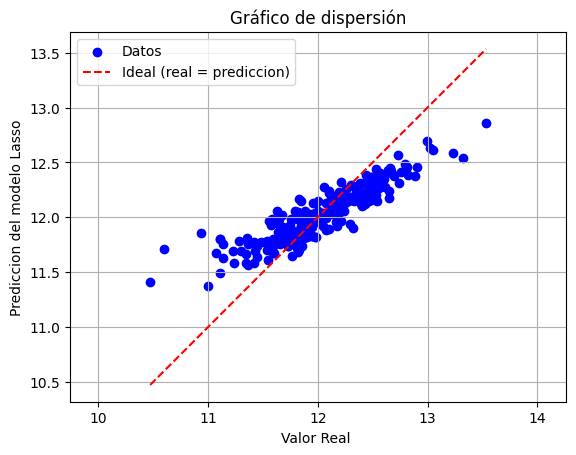

In [19]:
#7
# 1  Evaluación de Residuos: Para el mejor modelo que encontraste (probablemente RidgeCV o LassoCV), calcula los residuos ($y_{test} - \hat{y}$) y crea un gráfico de dispersión de los valores predichos vs. los residuos. ¿Observas algún patrón? Un patrón podría indicar que la relación no es puramente lineal.
#
# -  grafico de dispersion
plt.scatter(y_test, y_pred_lasso , color='blue', marker='o', label='Datos')

min_val = min(min(y_test), min(y_pred_lasso))
max_val = max(max(y_test), max(y_pred_lasso))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal (real = prediccion)')


plt.ylabel('Prediccion del modelo Lasso')
plt.xlabel('Valor Real ')
plt.title('Gráfico de dispersión')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

#Hay una correlacion positiva. se puede ver que la mayoria de los puntos se agrupan entre 11.6 y 12.5


In [13]:
#7
#Cambiar la Métrica de CV: En `LassoCV` y `RidgeCV`, el scoring por defecto es el error cuadrático negativo. Investiga cómo podrías usar el
# "mean_absolute_error" en su lugar. ¿Cambia el `alpha` seleccionado?
#2 - Cambiar Metrica de CV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso, Ridge


lasso_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 0.0066]}
ridge_grid = {'alpha': [100, 50, 75, 90, 150, 87]}

lasso_gs = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_grid,
    scoring='neg_mean_absolute_error',
)
lasso_gs.fit(X_train_scaled, y_train)

y_pred_lasso_cv_mae = lasso_gs.predict(X_test_scaled)
mse_lasso_cv_mse = mean_squared_error(y_test, y_pred_lasso_cv_mae)
r2_lasso_cv = r2_score(y_test, y_pred_lasso_cv_mae)



ridge_gs = GridSearchCV(
  Ridge(max_iter=10000),
  ridge_grid,
  scoring='neg_mean_absolute_error'
)

ridge_gs.fit(X_train_scaled, y_train)
y_pred_ridge_cv = lasso_gs.predict(X_test_scaled)
mse_ridge_cv_mse= mean_squared_error(y_test, y_pred_lasso_cv_mae)
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)

print('Lasso mejor alpha:', lasso_gs.best_params_['alpha'])
print('Lasso MAE CV:', -lasso_gs.best_score_)
print(f"Lasso MSE CV: {mse_lasso_cv_mse:.4f}")
print(f"R² de Lasso con CV MAE: {r2_lasso_cv:.4f}")


print('Ridge mejor alpha:', ridge_gs.best_params_['alpha'])
print('Ridge MAE CV:', -ridge_gs.best_score_)
print(f"Ridge MSE CV: {mse_ridge_cv_mse:.4f}")
print(f"Ridge R²: {r2_ridge_cv:.4f}")

# cambiando la funcion de costo el mejor alpha cambia

Lasso mejor alpha: 0.0001
Lasso MAE CV: 0.11989744709192304
Lasso MSE CV: 0.0303
R² de Lasso con CV MAE: 0.8375
Ridge mejor alpha: 50
Ridge MAE CV: 0.11973189411569493
Ridge MSE CV: 0.0303
Ridge R²: 0.8375


In [75]:
#7
# 3- implementar K-Fold a Mano: En lugar de usar `RidgeCV`, instancia un `KFold(n_splits=5)`, itera sobre los pliegues, entrena un modelo `Ridge` para un
# alpha fijo en cada pliegue y calcula el error promedio. Compara tu resultado con el de la clase `RidgeCV`.


kf = KFold(n_splits=5)
mse_array = []
for train_index, test_index in kf.split(X=X,y=y):
  scaler = StandardScaler()

  train_scaled = scaler.fit_transform(X.iloc[train_index])
  test_scaled = scaler.transform(X.iloc[test_index])

  feature_train_scaled = pd.DataFrame(train_scaled, columns=numeric_features)
  feature_test_scaled = pd.DataFrame(test_scaled, columns=numeric_features)

  target_train_data = y.iloc[train_index]
  target_test_data = y.iloc[test_index]

  model = Ridge(alpha=87.)
  model.fit(feature_train_scaled, target_train_data)
  y_model_pred = ridge_model.predict(feature_test_scaled)
  mse_array.append(mean_squared_error(target_test_data, y_model_pred))

print(f" kfold ridge mse: {np.array(mse_array).mean()}")
print(f" ridge mse: {mse_ridge}")

 kfold ridge mse: 0.030707103508918043
 ridge mse: 0.03098270948855318


In [26]:
###7
###6 Comparar MAE vs MSE: Calcula el `mean_absolute_error` (MAE) para todos los modelos finales (OLS, RidgeCV, LassoCV) en la escala logarítmica. ¿
# Por qué el MAE es menor que el MSE?
print(f"OLS MSR: {mse_ols:4f}")
print(f"OLS R²: {r2_ols:4f}")
print("\n")
print(f"Ridge MSE CV: {mse_ridge_cv_mse}")
print(f"Ridge R²: {r2_ridge_cv}")
print("\n")
print(f"Lasso MSE CV: {mse_lasso_cv_mse}")
print(f"R² de Lasso con CV MAE: {r2_lasso_cv}")
print("\n")

print("El MAE es menor al MSE porque el mae es solo un promedio de los errores absolutos. Mientras que el MSE es el promedio de los errores al cuadrado,"
      " lo que amplifica los errores grandes")


OLS MSR: 0.030324
OLS R²: 0.837502


Ridge MSE CV: 0.03032624243328248
Ridge R²: 0.8374895140817821


Lasso MSE CV: 0.03032624243328248
R² de Lasso con CV MAE: 0.8374895140817821


El MAE es menor al MSE porque el mae es solo un promedio de los errores absolutos. Mientras que el MSE es el promedio de los errores al cuadrado, lo que amplifica los errores grandes


In [32]:
##7
###7- Importancia de Características: Ordena los coeficientes del modelo `RidgeCV` final de mayor a menor en valor absoluto. ¿Cuáles son las 3 características
# más influyentes según este modelo?

print(f"{coef_df.sort_values(by ='Coef_Ridge_CV',ascending=False )['Coef_Ridge_CV']}")
print("\n la mas influyente es OverallQual")

OverallQual    0.129259
GrLivArea      0.112422
GarageCars     0.072479
YearBuilt      0.067699
TotalBsmtSF    0.048933
FullBath       0.006171
OpenPorchSF    0.005392
Name: Coef_Ridge_CV, dtype: float64

 la mas influyente es OveraAll Qual


             Coeficientes_Lasso_0.2  Coeficientes_Lasso_0.1  \
GrLivArea                  0.002797                0.056712   
OverallQual                0.113826                0.147911   
YearBuilt                  0.000000                0.004993   
TotalBsmtSF                0.000000                0.006045   
FullBath                   0.000000                0.000000   

             Coeficientes_Lasso_0.05  Coeficientes_Lasso_0.01  
GrLivArea                   0.089710                 0.116113  
OverallQual                 0.142973                 0.139021  
YearBuilt                   0.038457                 0.065232  
TotalBsmtSF                 0.025749                 0.041514  
FullBath                    0.000000                 0.000000  
[0.2, 0.1, 0.05, 0.01]


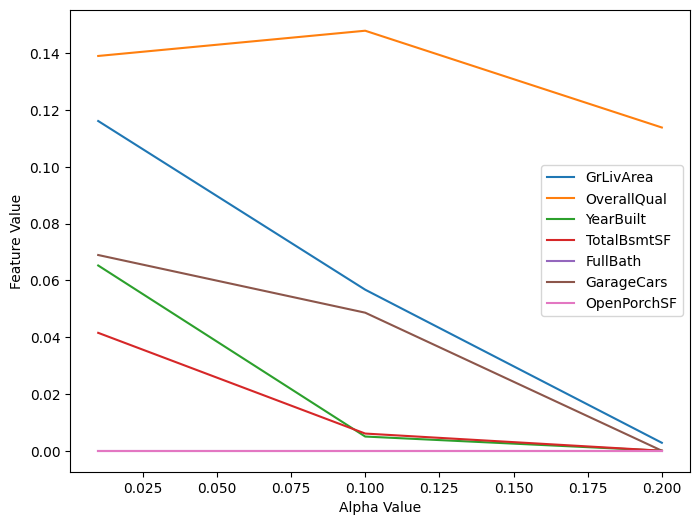



EL GRAFICO SE TIENE QUE LEER AL REVES, EL INICIO ES 0.200


In [114]:
#7
#8- Efecto del Alpha en Lasso: Crea un gráfico que muestre cómo cambian los coeficientes de Lasso a medida que `alpha` aumenta. Puedes usar la información
# almacenada en `lasso_cv.path_`.

alphas = [0.1, 0.05, 0.01]
lasso_ = Lasso(alpha=0.2)
lasso_.fit(X_train_scaled, y_train)
coef = pd.DataFrame(lasso_.coef_, index=numeric_features, columns=['Coeficientes_Lasso_0.2'])
for alpha in alphas:
  model = Lasso(alpha=alpha)
  model.fit(X_train_scaled, y_train)
  coef[f'Coeficientes_Lasso_{alpha}'] = model.coef_

alphas.insert(0,0.2)
plt.figure(figsize=(8, 6))
for index, row_series in coef.iterrows():
  values = []
  for key, value in row_series.items():
    values.append(value)
  plt.plot(alphas, values, label=index)

print(coef.head())
print(alphas)
plt.ylabel('Feature Value')
plt.xlabel('Alpha Value')
plt.legend()
plt.show()

print("\n")
print("EL GRAFICO SE TIENE QUE LEER AL REVES, EL INICIO ES 0.200")